This notebook reproduces Figure A7 in "Humidity’s role in population heat-health risk" by Kong et al.

In [1]:
import xarray as xr
import numpy as np
import dask
import matplotlib.pyplot as plt

In [2]:
# read in daily heatstroke numbers across 47 prefectures during summer of 2019-2019
heat_stk=np.load('../data/heatstroke_2010_2019.npy')

In [3]:
# select representative prefectures
sorted_indices = np.argsort(-np.nansum(heat_stk,axis=1))
indices=[sorted_indices[0],
         sorted_indices[9],
         sorted_indices[19],
         sorted_indices[29],
         sorted_indices[39],
         sorted_indices[-1]]
sub_heat_stk=heat_stk[indices,:]
# read in daily temperature for selected prefectures during summer of 2010-2019
t=np.load('../data/tas_daily_2010_2019.npy')[indices,:]

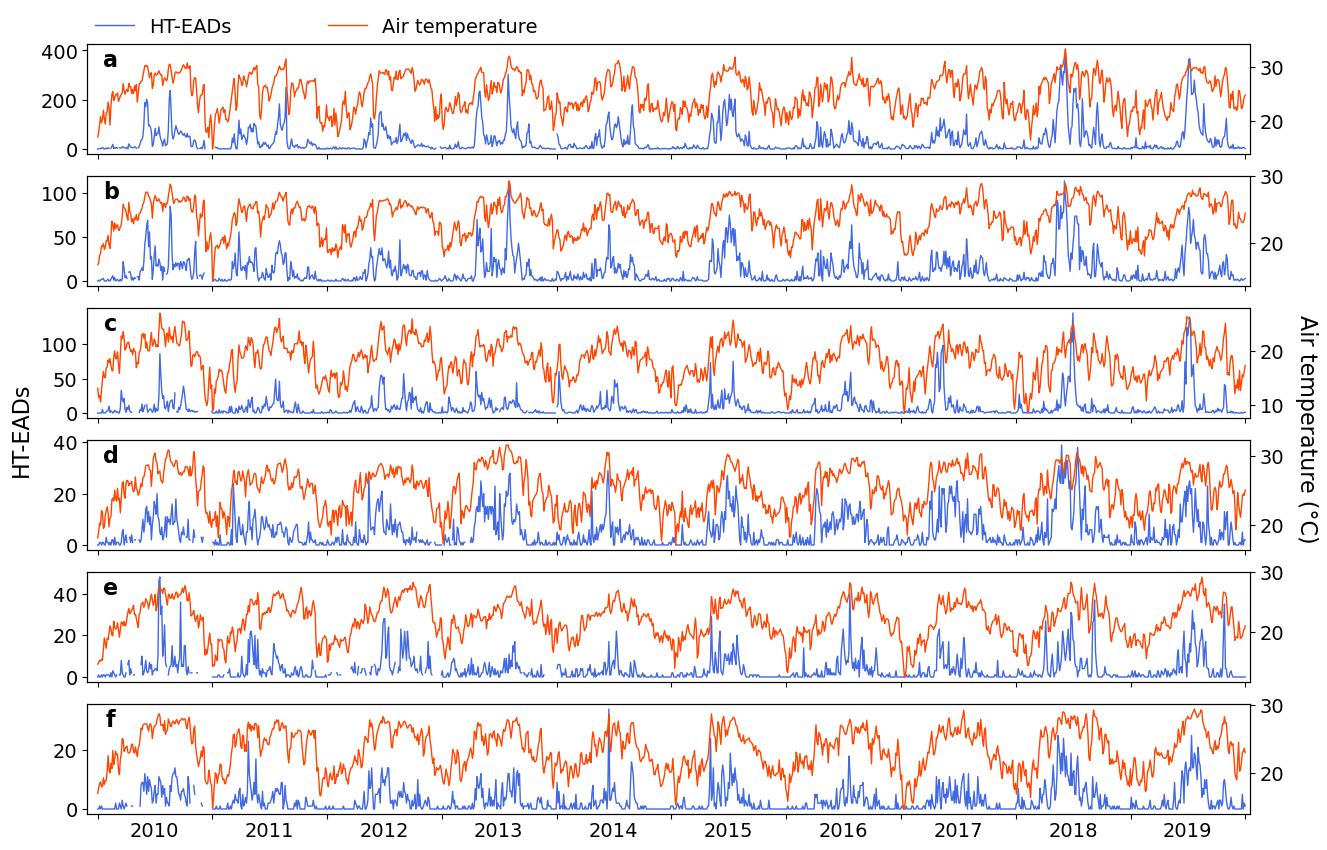

In [5]:
red='orangered'
blue = 'royalblue'


anno_opts = dict(xy=(0.02, 0.8), xycoords='axes fraction',va='baseline', ha='center')
anots=['a','b','c','d','e','f']
fig = plt.figure(figsize=(15,10))
axes=[]
axes2=[]
for k in range(6):
    x=np.arange(1,1221)
    ax = fig.add_subplot(6,1,k+1)
    axes.append(ax)
    ax.plot(x,sub_heat_stk[k,:],c='royalblue',linewidth=1,label='HT-EADs')
    ax2=ax.twinx()
    ax2.plot(x,t[k,:]-273.15,c='orangered',linewidth=1,label='Air temperature')
    axes2.append(ax2)
    #ax.set_ylim(-5,410)
    if k<5:
        ax.set_xticklabels([])
    ax.tick_params(axis='both', labelsize=14)
    ax2.tick_params(axis='both', labelsize=14)
    ax.set_xlim(-10,1225)
    ax.set_xticks([1,122.5,244.5,366.5,488.5,610.5,732.5,854.5,976.5,1098.5,1220])
    ax.set_xticklabels([])
    ax.annotate(anots[k], **anno_opts,fontsize=16,fontweight='bold')  
label_positions = [61, 183, 305,427,549,671,793,915,1037,1159]  # arbitrary y positions
labels = ['2010', '2011', '2012','2013','2014','2015','2016','2017','2018','2019']
for pos, label in zip(label_positions, labels):
    ax.text(x=pos, y=-0.15, s=label, va='center', ha='center', transform=ax.get_xaxis_transform(),fontsize=14)
        
ax.text(x=-80,y=3.5, s='HT-EADs', va='center', ha='center', transform=ax.get_xaxis_transform(),fontsize=16,rotation=90)
ax.text(x=1285,y=3.5, s='Air temperature (°C)', va='center', ha='center', transform=ax.get_xaxis_transform(),fontsize=16,rotation=270)

axes[0].set_yticks([0,200,400])
axes[1].set_yticks([0,50,100])
axes[2].set_yticks([0,50,100])
axes[3].set_yticks([0,20,40])
axes[4].set_yticks([0,20,40])
axes[5].set_yticks([0,20])

axes[0].legend(fontsize=14,frameon=False,loc=(0,1))
axes2[0].legend(fontsize=14,frameon=False,loc=(0.2,1))


**Fig. A7.** Daily heatstroke-related emergency ambulance dispatches (HT-EADs) and daily mean air temperature during June--September 2010--2019 for six prefectures ranked by annual HT-EAD frequency: (a) 1st, (b) 10th, (c) 20th, (d) 30th, (e) 40th, and (f) 47th.